### 1. Setup e Imports

In [1]:
import sys
import os
import time
import os
import subprocess
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


from pathlib import Path
from tqdm import tqdm
from sae.tools.experiment_utils import get_experiment_dir, get_metrics_dir, get_report_name
from sae.tools.naming_utils import get_checkpoint_dir, get_model_name, get_extras_id


# Configurar paths
project_root = Path('../../..').resolve()
sys.path.insert(0, str(project_root))

# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5060
Memoria disponible: 8.55 GB


In [2]:
# Configuración para visualización en PDF
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)  
np.set_printoptions(linewidth=100, edgeitems=3)

os.environ['COLUMNS'] = '100'

print(" Configuración para PDF lista")

 Configuración para PDF lista


In [3]:
NAMING_META = {
    'variante': 'topk',             
    'tecnica': 'batch-topk',               
    'capa': 6,                      
    'juegos': 5000,                   
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',
    'experiment_base_path': os.path.abspath('../../../experiments'),
    'extras': {
        'expansion': 16,   
        'k': 81,          
        'epochs': 1000,
        'patience': 20,
        'batch_size_tokens': 1024,
    }
}

print('\n Metadata del experimento:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata del experimento:
  variante: topk
  tecnica: batch-topk
  capa: 6
  juegos: 5000
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'k': 81, 'epochs': 1000, 'patience': 20, 'batch_size_tokens': 1024}


In [4]:
class BatchTopKSAE(nn.Module):
    def __init__(self, d_in: int, d_sae: int, k: int, k_aux: int = 512):
        super().__init__()
        self.d_in  = d_in
        self.d_sae = d_sae
        self.k     = k
        self.k_aux = k_aux

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self.W_dec.data = self.W_dec.data / self.W_dec.data.norm(dim=-1, keepdim=True)
        self.register_buffer('num_batches_not_active', torch.zeros(d_sae))

    def encode(self, x: torch.Tensor, threshold=None) -> torch.Tensor:
        x_norm, _, _ = self.preprocess_input(x)
        x_cent   = x_norm - self.b_dec
        pre_acts = F.relu(x_cent @ self.W_enc)
        return self._topk_activation(pre_acts, threshold=threshold)

    def _topk_activation(self, x: torch.Tensor, threshold=None) -> torch.Tensor:
        if threshold is None:
            acts_topk = torch.topk(x.flatten(), self.k * x.shape[0], dim=-1)
            return (
                torch.zeros_like(x.flatten())
                .scatter(-1, acts_topk.indices, acts_topk.values)
                .reshape(x.shape)
            )
        return torch.where(x > threshold, x, torch.zeros_like(x))

    def decode(self, hidden: torch.Tensor) -> torch.Tensor:
        return hidden @ self.W_dec + self.b_dec

    def preprocess_input(self, x: torch.Tensor):
        x_mean = x.mean(dim=-1, keepdim=True)
        x = x - x_mean
        x_std = x.std(dim=-1, keepdim=True)
        x = x / (x_std + 1e-5)
        return x, x_mean, x_std

    def postprocess_output(self, x_reconstruct, x_mean, x_std):
        return x_reconstruct * x_std + x_mean

    def forward(self, x: torch.Tensor, threshold=None):
        x_norm, x_mean, x_std = self.preprocess_input(x)
        x_cent   = x_norm - self.b_dec
        pre_acts = F.relu(x_cent @ self.W_enc)
        hidden   = self._topk_activation(pre_acts, threshold=threshold)
        recon    = self.postprocess_output(self.decode(hidden), x_mean, x_std)
        return recon, hidden, pre_acts

print("BatchTopKSAE definida")

BatchTopKSAE definida


### 2. Cargar Datos

In [5]:
# Cargar activaciones pre-SAE
activations_path = project_root / "activations" / "data" / "layer6_2000games.npy"
activations_full = np.load(activations_path)
activations = activations_full

print(f"Activaciones del modelo:")
print(f"  Shape original: {activations_full.shape}")
print(f"  Shape final: {activations.shape}")
print(f"  Memoria: {activations.nbytes / (1024**2):.2f} MB")

Activaciones del modelo:
  Shape original: (118000, 512)
  Shape final: (118000, 512)
  Memoria: 230.47 MB


In [6]:
# Cargar ground truth de BSPs
bsp_gt_path = project_root / "metrics" / "02_data" / "bsp_ground_truth_2000games.npy"
bsp_names_path = project_root / "metrics" / "02_data" / "bsp_ground_truth_2000games.names.npy"

bsp_ground_truth_full = np.load(bsp_gt_path)
bsp_names = np.load(bsp_names_path, allow_pickle=True)
bsp_ground_truth = bsp_ground_truth_full
print(f"\nGround truth BSPs:")
print(f"  Shape original: {bsp_ground_truth_full.shape}")
print(f"  Shape final: {bsp_ground_truth.shape}")
print(f"  Total BSPs: {len(bsp_names)}")


Ground truth BSPs:
  Shape original: (118000, 326)
  Shape final: (118000, 326)
  Total BSPs: 326


### 3. Cargar SAE y Extraer Features

In [7]:
# Configuración del SAE
input_dim = 512
hidden_dim = 8192

# Construir ruta del modelo usando naming_utils
checkpoint_dir = get_checkpoint_dir(
    NAMING_META['base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos']
)
extras_id = get_extras_id(checkpoint_dir, NAMING_META['extras']) if NAMING_META.get('extras') else None

model_name = get_model_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'best',
    extras_id=extras_id
)
model_path = checkpoint_dir / model_name

# Cargar modelo BatchTopK
sae = BatchTopKSAE(d_in=input_dim, d_sae=hidden_dim, k=NAMING_META['extras']['k']).to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)
sae.load_state_dict(checkpoint['model_state_dict'])
sae.eval()

print(f"SAE cargado:")
print(f"  Path: {model_path}")
print(f"  Input: {input_dim}, Hidden: {hidden_dim}, k: {NAMING_META['extras']['k']}")
print(f"  Expansion: {hidden_dim/input_dim}x")

SAE cargado:
  Path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_topk\sae_batch-topk_topk\5000games\sae_topk_batch-topk_l6_5000g_ex2_best.pt
  Input: 512, Hidden: 8192, k: 81
  Expansion: 16.0x


In [8]:
# Extraer features del SAE en GPU
print("Extrayendo features del SAE...")
activations_tensor = torch.from_numpy(activations).float().to(device)

# Estimar threshold con mini-batch 
with torch.no_grad():
    sample = activations_tensor[:4096]
    x_s, _, _ = sae.preprocess_input(sample)
    pre_s = F.relu((x_s - sae.b_dec) @ sae.W_enc)
    threshold = torch.topk(pre_s.flatten(), sae.k * 4096).values.min().item()
print(f"Threshold estimado: {threshold:.6f}")

# Encoding completo con operación in-place (igual que Matryoshka en eval)
with torch.no_grad():
    x_norm, _, _ = sae.preprocess_input(activations_tensor)
    x_cent = x_norm - sae.b_dec
    pre_acts = F.relu(x_cent @ sae.W_enc)
    pre_acts.mul_(pre_acts > threshold)  # in-place: no duplica memoria
    sae_features = pre_acts

del activations_tensor
torch.cuda.empty_cache()

print(f"\nFeatures SAE:")
print(f"  Shape: {sae_features.shape}")
print(f"  Device: {sae_features.device}")
print(f"  Sparsity: {(sae_features == 0).float().mean():.2%}")
print(f"  Activaciones promedio: {(sae_features > 0).sum(dim=1).float().mean():.1f}")

Extrayendo features del SAE...
Threshold estimado: 0.719861

Features SAE:
  Shape: torch.Size([118000, 8192])
  Device: cuda:0
  Sparsity: 99.02%
  Activaciones promedio: 80.6


### 4. Filtrar BSPs de Piezas

Coverage solo usa las 128 BSPs de piezas (mías/oponente), sin vacías.

In [9]:
# =============================================
# CONFIGURACIÓN DE FILTRADO DE BSPs
# =============================================
USE_PLAYER   = False   # BSPs perspectiva del jugador (1 y 2)
USE_ABSOLUTE = True  # BSPs absolutas negro/blanco (B y W)
USE_STRATEGIC = False # BSPs especiales (BSP_)

bsp_pieces_indices = []
bsp_pieces_names = []

for i, name in enumerate(bsp_names):
    include = False
    if USE_PLAYER and len(name) == 6 and name.startswith('BSP') and (name.endswith('1') or name.endswith('2')):
        include = True
    if USE_ABSOLUTE and (name.endswith('B') or name.endswith('W')):
        include = True
    if USE_STRATEGIC and name.startswith('BSP_'):
        include = True
    if include:
        bsp_pieces_indices.append(i)
        bsp_pieces_names.append(name)

bsp_pieces_indices = np.array(bsp_pieces_indices)
bsp_pieces_gt = bsp_ground_truth[:, bsp_pieces_indices]

# Convertir a tensor en GPU
bsp_pieces_gt_tensor = torch.from_numpy(bsp_pieces_gt).bool().to(device)

# Identificador del filtrado (para naming de archivos de salida)
parts = []
if USE_PLAYER: parts.append("player")
if USE_ABSOLUTE: parts.append("absolute")
if USE_STRATEGIC: parts.append("strategic")
filter_suffix = "_".join(parts) if parts else "none"

print(f"BSPs seleccionadas para Coverage:")
print(f"  Player: {USE_PLAYER} | Absolute: {USE_ABSOLUTE} | Strategic: {USE_STRATEGIC}")
print(f"  Total: {len(bsp_pieces_indices)}")
print(f"  Shape: {bsp_pieces_gt_tensor.shape}")
print(f"  Device: {bsp_pieces_gt_tensor.device}")
print(f"  Primeras 5: {', '.join(bsp_pieces_names[:5])}")
print(f"  Últimas 5: {', '.join(bsp_pieces_names[-5:])}")
print(f"  Filter suffix: {filter_suffix}")


BSPs seleccionadas para Coverage:
  Player: False | Absolute: True | Strategic: False
  Total: 128
  Shape: torch.Size([118000, 128])
  Device: cuda:0
  Primeras 5: BSPA1B, BSPA1W, BSPA2B, BSPA2W, BSPA3B
  Últimas 5: BSPH6W, BSPH7B, BSPH7W, BSPH8B, BSPH8W
  Filter suffix: absolute


### 5. Implementación de Coverage

#### Estrategia de optimización:
1. **Vectorización**: Procesar múltiples features en paralelo usando operaciones matriciales
2. **Batch processing**: Dividir en chunks para no saturar memoria GPU
3. **Pre-cálculo**: Calcular máximos una sola vez
4. **Early stopping**: Terminar cuando F1 ≈ 1.0

In [10]:
def fast_f1_score_gpu(y_true, y_pred, eps=1e-8):
    """
    F1 score vectorizado en GPU.
    
    Args:
        y_true: Tensor (n_positions,) booleano
        y_pred: Tensor (n_positions, n_candidates) booleano
    
    Returns:
        f1_scores: Tensor (n_candidates,)
    """
    # y_true: (n_positions,) -> expand to (n_positions, 1)
    y_true_expanded = y_true.unsqueeze(1)  # (n_positions, 1)
    
    # Calcular TP, FP, FN
    tp = (y_true_expanded & y_pred).sum(dim=0).float()  # (n_candidates,)
    fp = (~y_true_expanded & y_pred).sum(dim=0).float()
    fn = (y_true_expanded & ~y_pred).sum(dim=0).float()
    
    # Precision y Recall
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    
    # F1
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    return f1


def calculate_coverage_gpu_optimized(
    sae_features,  # Tensor (n_positions, n_features) en GPU
    bsp_ground_truth,  # Tensor (n_positions, n_bsps) en GPU, bool
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    batch_size_features=512,  # Procesar 512 features a la vez
    f_max=None,  # ← AGREGAR
    verbose=True
):
    """
    Calcula Coverage de forma optimizada para GPU.
    
    Procesa múltiples features y thresholds en paralelo usando operaciones matriciales.
    """
    n_positions, n_features = sae_features.shape
    n_bsps = bsp_ground_truth.shape[1]
    n_thresholds = len(thresholds)
    
    if verbose:
        print("="*60)
        print("CALCULATING COVERAGE (GPU OPTIMIZED)")
        print("="*60)
        print(f"Positions: {n_positions:,}")
        print(f"SAE Features: {n_features:,}")
        print(f"BSPs: {n_bsps}")
        print(f"Thresholds: {n_thresholds}")
        print(f"Batch size (features): {batch_size_features}")
        print(f"Total evaluations: {n_bsps * n_features * n_thresholds:,}")
        print("="*60)
    
    # Pre-calcular máximos de features
    if f_max is None:
        f_max = sae_features.max(dim=0)[0]
    active_features = (f_max > 0).nonzero(as_tuple=True)[0]
    n_active = len(active_features)
    
    if verbose:
        print(f"\nActive features: {n_active:,}/{n_features:,} ({n_active/n_features*100:.1f}%)")
        print(f"Reduced evaluations: {n_bsps * n_active * n_thresholds:,}")
        print()
    
    # Almacenar resultados
    best_f1s = torch.zeros(n_bsps, device=sae_features.device)
    best_features = torch.full((n_bsps,), -1, dtype=torch.long, device=sae_features.device)
    best_thresholds = torch.full((n_bsps,), -1.0, device=sae_features.device)
    
    thresholds_tensor = torch.tensor(thresholds, device=sae_features.device)
    
    # Procesar cada BSP
    pbar = tqdm(range(n_bsps), desc="Processing BSPs") if verbose else range(n_bsps)
    
    for bsp_idx in pbar:
        bsp_labels = bsp_ground_truth[:, bsp_idx]  # (n_positions,)
        
        # Skip si la BSP nunca está activa
        if not bsp_labels.any():
            continue
        
        # Procesar features activas en batches
        for batch_start in range(0, n_active, batch_size_features):
            batch_end = min(batch_start + batch_size_features, n_active)
            batch_features_idx = active_features[batch_start:batch_end]
            
            # Extraer features del batch
            batch_activations = sae_features[:, batch_features_idx]  # (n_positions, batch_size)
            batch_f_max = f_max[batch_features_idx]  # (batch_size,)
            
            # Para cada threshold, binarizar TODAS las features del batch a la vez
            for t in thresholds_tensor:
                # Binarizar: (n_positions, batch_size)
                predictions = batch_activations > (t * batch_f_max.unsqueeze(0))
                
                # Calcular F1 para todas las features del batch
                f1_scores = fast_f1_score_gpu(bsp_labels, predictions)  # (batch_size,)
                
                # Encontrar la mejor en este batch
                max_f1, max_idx_in_batch = f1_scores.max(dim=0)
                
                # Actualizar si es mejor que lo visto hasta ahora
                if max_f1 > best_f1s[bsp_idx]:
                    best_f1s[bsp_idx] = max_f1
                    best_features[bsp_idx] = batch_features_idx[max_idx_in_batch]
                    best_thresholds[bsp_idx] = t
            
            # Early stopping: si ya es casi perfecto, no revisar más batches
            if best_f1s[bsp_idx] >= 0.999:
                break
    
    # Calcular Coverage (macro-average)
    coverage = best_f1s.mean().item()
    
    # Convertir a CPU para retornar
    best_f1s_cpu = best_f1s.cpu().numpy()
    best_features_cpu = best_features.cpu().numpy()
    best_thresholds_cpu = best_thresholds.cpu().numpy()
    
    return coverage, best_f1s_cpu, best_features_cpu, best_thresholds_cpu

print(" Funciones de Coverage GPU definidas")

 Funciones de Coverage GPU definidas


### 6. Calcular Coverage

In [11]:
# Medir tiempo de ejecución
start_time = time.time()

coverage, best_f1s, best_features, best_thresholds = calculate_coverage_gpu_optimized(
    sae_features,
    bsp_pieces_gt_tensor,
    batch_size_features=512,  # Ajustar según memoria GPU
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "="*60)
print("RESULTADO COVERAGE")
print("="*60)
print(f"Coverage Score: {coverage:.4f}")
print(f"Objetivo (paper): 0.52")
print(f"Diferencia: {coverage - 0.52:+.4f}")
print(f"\nTiempo de ejecución: {elapsed_time:.2f} seg")
print(f"                      ({elapsed_time/60:.2f} min)")
print("="*60)

CALCULATING COVERAGE (GPU OPTIMIZED)
Positions: 118,000
SAE Features: 8,192
BSPs: 128
Thresholds: 10
Batch size (features): 512
Total evaluations: 10,485,760

Active features: 8,192/8,192 (100.0%)
Reduced evaluations: 10,485,760



Processing BSPs: 100%|██████████| 128/128 [04:50<00:00,  2.27s/it]


RESULTADO COVERAGE
Coverage Score: 0.4222
Objetivo (paper): 0.52
Diferencia: -0.0978

Tiempo de ejecución: 290.75 seg
                      (4.85 min)


### 7. Análisis de Resultados

In [12]:
# Estadísticas de distribución de F1 scores
print("Distribución de F1 scores:")
print(f"  Mínimo: {best_f1s.min():.4f}")
print(f"  Máximo: {best_f1s.max():.4f}")
print(f"  Media: {best_f1s.mean():.4f}")
print(f"  Mediana: {np.median(best_f1s):.4f}")
print(f"  Std: {best_f1s.std():.4f}")
print()
print(f"BSPs con F1 > 0.8: {(best_f1s > 0.8).sum()} ({(best_f1s > 0.8).mean()*100:.1f}%)")
print(f"BSPs con F1 > 0.5: {(best_f1s > 0.5).sum()} ({(best_f1s > 0.5).mean()*100:.1f}%)")
print(f"BSPs con F1 < 0.2: {(best_f1s < 0.2).sum()} ({(best_f1s < 0.2).mean()*100:.1f}%)")

Distribución de F1 scores:
  Mínimo: 0.3638
  Máximo: 0.5247
  Media: 0.4222
  Mediana: 0.4070
  Std: 0.0397

BSPs con F1 > 0.8: 0 (0.0%)
BSPs con F1 > 0.5: 7 (5.5%)
BSPs con F1 < 0.2: 0 (0.0%)


In [13]:
# Top 5 BSPs mejor detectadas
top_indices = np.argsort(best_f1s)[-5:][::-1]

print("\nTop 5 BSPs mejor detectadas:")
print("="*60)
print(f"{'BSP':<10} {'F1':<8} {'Feature':<10} {'Threshold':<10}")
print("-"*60)
for idx in top_indices:
    bsp_name = bsp_pieces_names[idx]
    f1 = best_f1s[idx]
    feat = best_features[idx]
    thresh = best_thresholds[idx]
    print(f"{bsp_name:<10} {f1:<8.4f} {feat:<10} {thresh:<10.1f}")


Top 5 BSPs mejor detectadas:
BSP        F1       Feature    Threshold 
------------------------------------------------------------
BSPH8W     0.5247   213        0.2       
BSPA8B     0.5156   3843       0.1       
BSPA1B     0.5100   3129       0.1       
BSPH1B     0.5077   228        0.0       
BSPH1W     0.5060   228        0.0       


In [14]:
# Bottom 5 BSPs peor detectadas
bottom_indices = np.argsort(best_f1s)[:5]

print("\nBottom 5 BSPs peor detectadas:")
print("="*60)
print(f"{'BSP':<10} {'F1':<8} {'Feature':<10} {'Threshold':<10}")
print("-"*60)
for idx in bottom_indices:
    bsp_name = bsp_pieces_names[idx]
    f1 = best_f1s[idx]
    feat = best_features[idx]
    thresh = best_thresholds[idx]
    print(f"{bsp_name:<10} {f1:<8.4f} {feat:<10} {thresh:<10.1f}")


Bottom 5 BSPs peor detectadas:
BSP        F1       Feature    Threshold 
------------------------------------------------------------
BSPA5B     0.3638   7861       0.0       
BSPA6W     0.3656   735        0.0       
BSPA4W     0.3679   3803       0.0       
BSPH5W     0.3695   5806       0.0       
BSPF8B     0.3715   533        0.0       


In [15]:
# Distribución de thresholds óptimos
unique_thresholds, counts = np.unique(best_thresholds, return_counts=True)

print("\nDistribución de thresholds óptimos:")
print("="*60)
for t, count in zip(unique_thresholds, counts):
    if t >= 0:  # Ignorar -1 (BSPs sin match)
        percentage = count / len(best_thresholds) * 100
        print(f"Threshold {t:.1f}: {count:3d} BSPs ({percentage:.1f}%)")


Distribución de thresholds óptimos:
Threshold 0.0: 114 BSPs (89.1%)
Threshold 0.1:  12 BSPs (9.4%)
Threshold 0.2:   2 BSPs (1.6%)


### 8. Diagramas

In [16]:
def plot_bsp_histogram(BSP_HISTOGRAMA, sae_features, bsp_pieces_names, bsp_pieces_gt_tensor, 
                        best_features, best_thresholds, best_f1s, n_bins=20):
    
    # Extraer datos de la BSP
    bsp_idx_hist   = bsp_pieces_names.index(BSP_HISTOGRAMA)
    neurona_hist   = best_features[bsp_idx_hist]
    threshold_hist = best_thresholds[bsp_idx_hist]
    f1_hist        = best_f1s[bsp_idx_hist]
    f_max_hist     = sae_features[:, neurona_hist].max().item()

    # Activaciones y ground truth
    activaciones = sae_features[:, neurona_hist].cpu().numpy()
    gt           = bsp_pieces_gt_tensor[:, bsp_idx_hist].cpu().numpy()
    umbral       = threshold_hist * f_max_hist

    # Clasificar
    predicho = (activaciones > umbral).astype(int)
    tp_mask  = (gt == 1) & (predicho == 1)
    fp_mask  = (gt == 0) & (predicho == 1)
    tn_mask  = (gt == 0) & (predicho == 0)
    fn_mask  = (gt == 1) & (predicho == 0)

    # Bins
    bins        = np.linspace(0, activaciones.max(), n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width   = bins[1] - bins[0]

    tp_counts, _ = np.histogram(activaciones[tp_mask], bins=bins)
    fp_counts, _ = np.histogram(activaciones[fp_mask], bins=bins)
    tn_counts, _ = np.histogram(activaciones[tn_mask], bins=bins)
    fn_counts, _ = np.histogram(activaciones[fn_mask], bins=bins)

    left_mask  = bin_centers <= umbral
    right_mask = bin_centers > umbral

    # Graficar
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(bin_centers[left_mask], tn_counts[left_mask],
           width=bin_width, color='steelblue', alpha=0.9,
           label='TN (GT=0, pred=0)', align='center')
    ax.bar(bin_centers[left_mask], fn_counts[left_mask],
           width=bin_width, bottom=tn_counts[left_mask],
           color='lightcoral', alpha=0.9,
           label='FN (GT=1, pred=0)', align='center')
    ax.bar(bin_centers[right_mask], tp_counts[right_mask],
           width=bin_width, color='green', alpha=0.9,
           label='TP (GT=1, pred=1)', align='center')
    ax.bar(bin_centers[right_mask], fp_counts[right_mask],
           width=bin_width, bottom=tp_counts[right_mask],
           color='orange', alpha=0.9,
           label='FP (GT=0, pred=1)', align='center')

    # Números TN
    for i, x in enumerate(bin_centers[left_mask]):
        total = tn_counts[left_mask][i] + fn_counts[left_mask][i]
        if tn_counts[left_mask][i] > 0:
            ax.text(x, total + 0.3, str(tn_counts[left_mask][i]),
                    ha='center', va='bottom', fontsize=7, color='steelblue')

    # Números TP
    for i, x in enumerate(bin_centers[right_mask]):
        total = tp_counts[right_mask][i] + fp_counts[right_mask][i]
        if tp_counts[right_mask][i] > 0:
            ax.text(x, total + 0.3, str(tp_counts[right_mask][i]),
                    ha='center', va='bottom', fontsize=7, color='green')

    # Umbral
    ax.axvline(x=umbral, color='red', linewidth=2, linestyle='--',
               label=f'Umbral = {threshold_hist:.1f} × {f_max_hist:.3f} = {umbral:.4f}')

    ax.set_xlabel('Activación de la neurona')
    ax.set_ylabel('Conteo de tableros')
    ax.set_title(f'Histograma BSP: {BSP_HISTOGRAMA} | Neurona: {neurona_hist} | F1: {f1_hist:.4f}')
    ax.legend()
    ax.text(umbral * 0.5, ax.get_ylim()[1] * 0.95, 'predicho = 0',
            ha='center', fontsize=10, color='gray')
    ax.text(umbral + (activaciones.max() - umbral) * 0.5, ax.get_ylim()[1] * 0.95, 'predicho = 1',
            ha='center', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

    print(f"\nResumen:")
    print(f"  TP: {tp_mask.sum()} | FP: {fp_mask.sum()}")
    print(f"  TN: {tn_mask.sum()} | FN: {fn_mask.sum()}")
    print(f"  F1: {f1_hist:.4f}")

print("✓ Función plot_bsp_histogram definida")

✓ Función plot_bsp_histogram definida


BSP seleccionada automáticamente: BSPH8W  (F1=0.5247, filter=absolute)


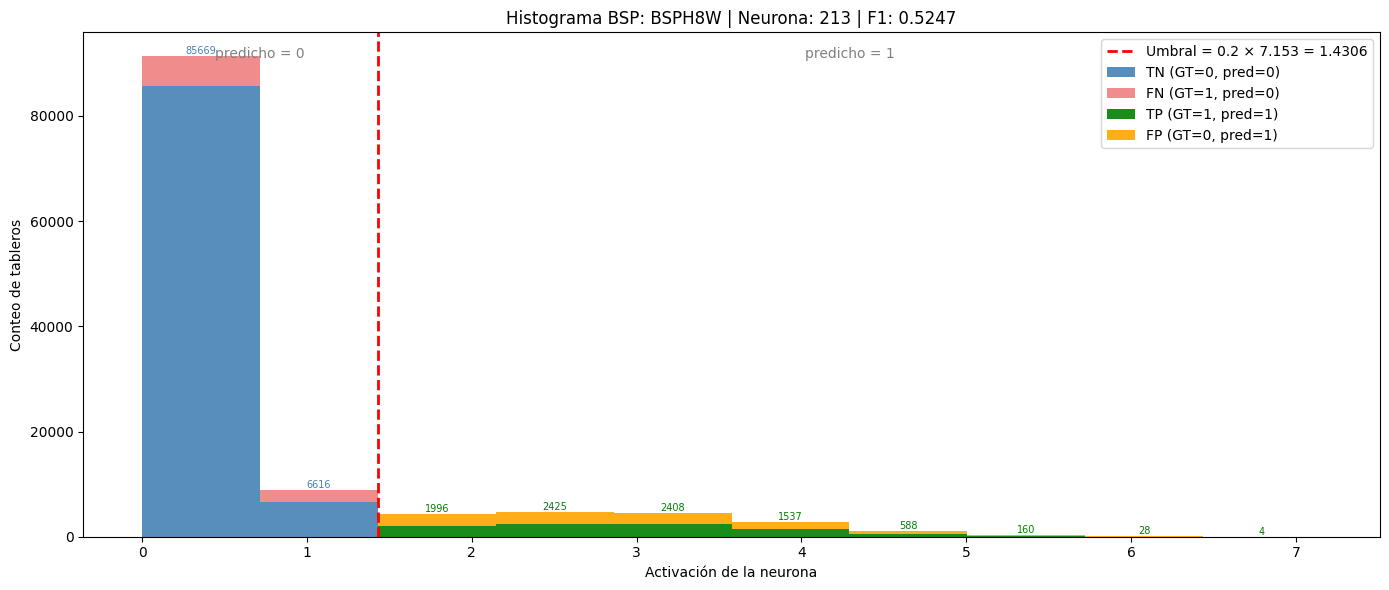


Resumen:
  TP: 9146 | FP: 8730
  TN: 92285 | FN: 7839
  F1: 0.5247


In [17]:
# Seleccionar automáticamente la mejor BSP detectada
best_bsp_idx = int(np.argmax(best_f1s))
BSP_HISTOGRAMA = bsp_pieces_names[best_bsp_idx]
print(f"BSP seleccionada automáticamente: {BSP_HISTOGRAMA}  (F1={best_f1s[best_bsp_idx]:.4f}, filter={filter_suffix})")

plot_bsp_histogram(
    BSP_HISTOGRAMA       = BSP_HISTOGRAMA,
    sae_features         = sae_features,
    bsp_pieces_names     = bsp_pieces_names,
    bsp_pieces_gt_tensor = bsp_pieces_gt_tensor,
    best_features        = best_features,
    best_thresholds      = best_thresholds,
    best_f1s             = best_f1s,
    n_bins               = 10
)

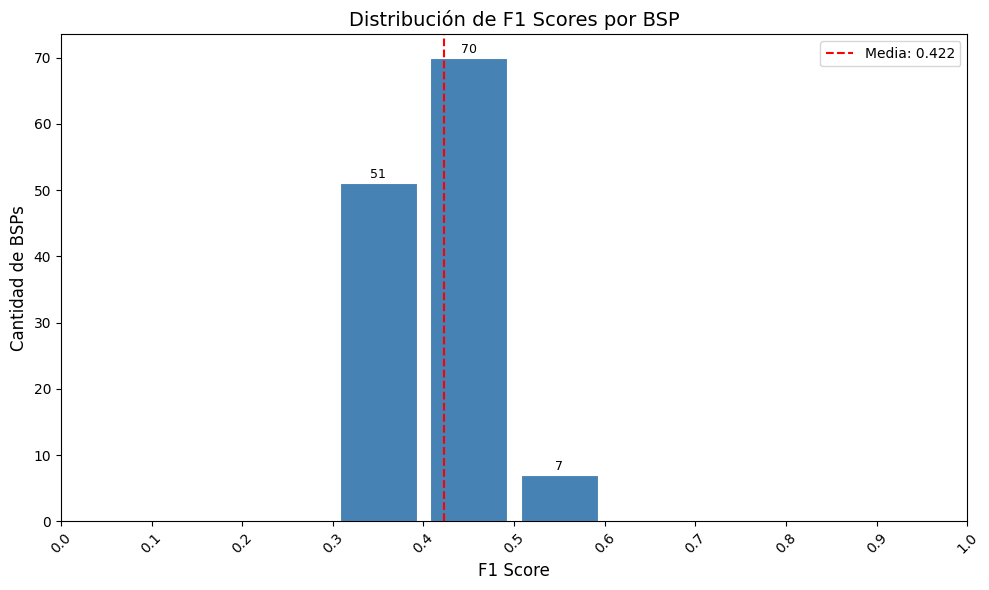

Total BSPs: 128
Media F1: 0.4222
BSPs con F1 = 0: 0
BSPs con F1 > 0.5: 7
BSPs con F1 > 0.9: 0


In [18]:
def plot_f1_distribution(best_f1s, bsp_pieces_names, n_bins=10):
    """
    Gráfico 1: Distribución de F1 scores por BSP.
    
    Args:
        best_f1s: array numpy con el mejor F1 score de cada BSP
        bsp_pieces_names: lista con los nombres de las BSPs
        n_bins: número de bins del histograma
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = np.linspace(0, 1, n_bins + 1)
    counts, edges = np.histogram(best_f1s, bins=bins)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    bin_width = edges[1] - edges[0]
    
    bars = ax.bar(
        bin_centers, counts,
        width=bin_width * 0.85,
        color='steelblue',
        edgecolor='white',
        linewidth=0.8
    )
    
    # Etiquetas encima de cada barra
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(count),
                ha='center', va='bottom', fontsize=9
            )
    
    ax.set_xlabel('F1 Score', fontsize=12)
    ax.set_ylabel('Cantidad de BSPs', fontsize=12)
    ax.set_title('Distribución de F1 Scores por BSP', fontsize=14)
    ax.set_xticks(bins)
    ax.set_xticklabels([f'{b:.1f}' for b in bins], rotation=45)
    ax.set_xlim(0, 1)
    
    # Línea de la media
    mean_f1 = best_f1s.mean()
    ax.axvline(mean_f1, color='red', linestyle='--', linewidth=1.5, label=f'Media: {mean_f1:.3f}')
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total BSPs: {len(best_f1s)}")
    print(f"Media F1: {mean_f1:.4f}")
    print(f"BSPs con F1 = 0: {(best_f1s == 0).sum()}")
    print(f"BSPs con F1 > 0.5: {(best_f1s > 0.5).sum()}")
    print(f"BSPs con F1 > 0.9: {(best_f1s > 0.9).sum()}")


# Ejecutar
plot_f1_distribution(best_f1s, bsp_pieces_names)

In [19]:
# Extraer f_max de las features activas
f_max = sae_features.max(dim=0)[0]  # (n_features,)

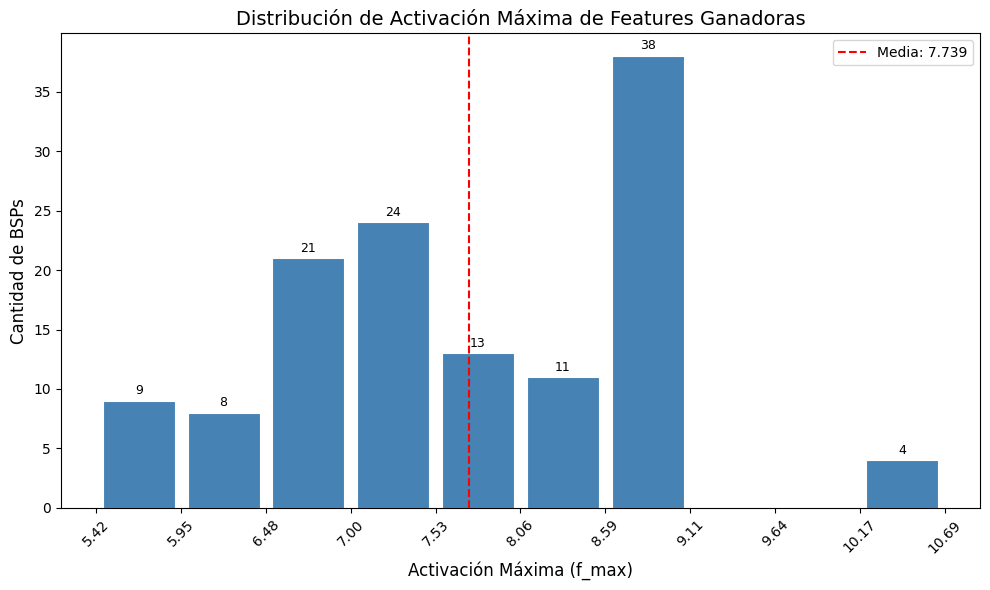

Total BSPs con feature ganadora: 128
BSPs sin feature ganadora: 0
Media f_max ganadora: 7.7388
Mínimo f_max: 5.4226
Máximo f_max: 10.6937


In [20]:
def plot_max_activation_distribution(best_features, f_max, bsp_pieces_names, n_bins=10):
    """
    Gráfico 2: Distribución de activación máxima de la feature ganadora por BSP.
    
    Args:
        best_features: array numpy con el índice de la feature ganadora de cada BSP
        f_max: tensor con la activación máxima de cada feature
        bsp_pieces_names: lista con los nombres de las BSPs
        n_bins: número de bins del histograma
    """
    # Obtener f_max de la feature ganadora de cada BSP
    # Ignorar BSPs sin feature ganadora (best_features == -1)
    valid_mask = best_features >= 0
    valid_features = best_features[valid_mask]
    f_max_winners = f_max[valid_features].cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bins = np.linspace(f_max_winners.min(), f_max_winners.max(), n_bins + 1)
    counts, edges = np.histogram(f_max_winners, bins=bins)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    bin_width = edges[1] - edges[0]
    
    bars = ax.bar(
        bin_centers, counts,
        width=bin_width * 0.85,
        color='steelblue',
        edgecolor='white',
        linewidth=0.8
    )
    
    # Etiquetas encima de cada barra
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(count),
                ha='center', va='bottom', fontsize=9
            )
    
    # Línea de la media
    mean_fmax = f_max_winners.mean()
    ax.axvline(mean_fmax, color='red', linestyle='--', linewidth=1.5, 
               label=f'Media: {mean_fmax:.3f}')
    ax.legend(fontsize=10)
    
    ax.set_xlabel('Activación Máxima (f_max)', fontsize=12)
    ax.set_ylabel('Cantidad de BSPs', fontsize=12)
    ax.set_title('Distribución de Activación Máxima de Features Ganadoras', fontsize=14)
    ax.set_xticks(edges)
    ax.set_xticklabels([f'{b:.2f}' for b in edges], rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total BSPs con feature ganadora: {valid_mask.sum()}")
    print(f"BSPs sin feature ganadora: {(~valid_mask).sum()}")
    print(f"Media f_max ganadora: {mean_fmax:.4f}")
    print(f"Mínimo f_max: {f_max_winners.min():.4f}")
    print(f"Máximo f_max: {f_max_winners.max():.4f}")


# Ejecutar
plot_max_activation_distribution(best_features, f_max, bsp_pieces_names)

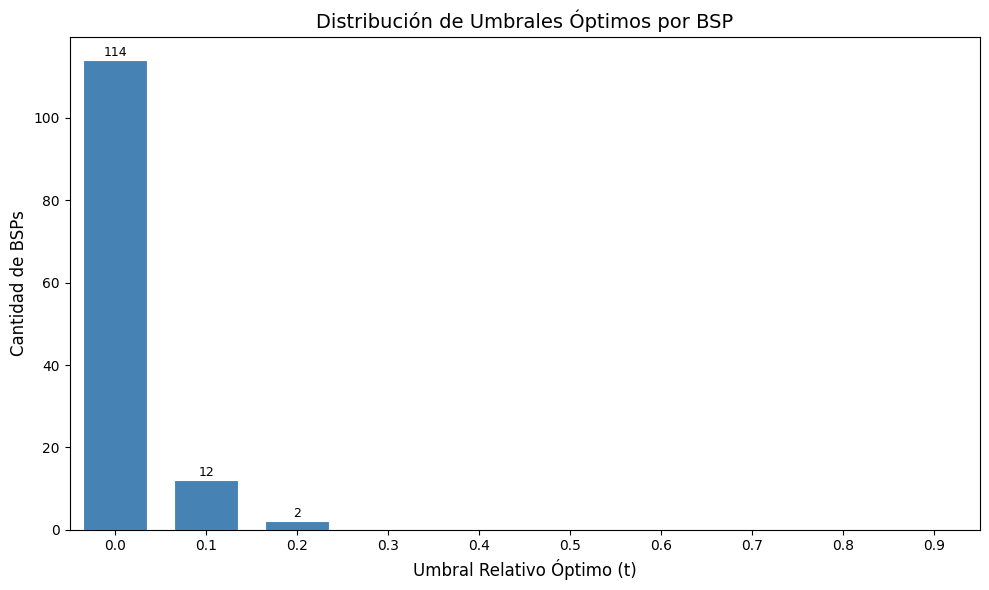

Total BSPs con umbral óptimo: 128
BSPs sin feature ganadora: 0
Umbral más frecuente: 0.0


In [21]:
def plot_threshold_distribution(best_thresholds, bsp_pieces_names):
    """
    Gráfico 3: Distribución de umbrales óptimos por BSP.
    
    Args:
        best_thresholds: array numpy con el umbral óptimo de cada BSP
        bsp_pieces_names: lista con los nombres de las BSPs
    """
    # Ignorar BSPs sin feature ganadora (best_thresholds == -1)
    valid_mask = best_thresholds >= 0
    valid_thresholds = best_thresholds[valid_mask]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Los umbrales son discretos: 0.0, 0.1, 0.2, ..., 0.9
    threshold_values = np.arange(0.0, 1.0, 0.1)
    counts = [(np.abs(valid_thresholds - t) < 0.05).sum() for t in threshold_values]
    
    bars = ax.bar(
        threshold_values, counts,
        width=0.07,
        color='steelblue',
        edgecolor='white',
        linewidth=0.8
    )
    
    # Etiquetas encima de cada barra
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(count),
                ha='center', va='bottom', fontsize=9
            )
    
    ax.set_xlabel('Umbral Relativo Óptimo (t)', fontsize=12)
    ax.set_ylabel('Cantidad de BSPs', fontsize=12)
    ax.set_title('Distribución de Umbrales Óptimos por BSP', fontsize=14)
    ax.set_xticks(threshold_values)
    ax.set_xticklabels([f'{t:.1f}' for t in threshold_values])
    ax.set_xlim(-0.05, 0.95)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total BSPs con umbral óptimo: {valid_mask.sum()}")
    print(f"BSPs sin feature ganadora: {(~valid_mask).sum()}")
    print(f"Umbral más frecuente: {threshold_values[np.argmax(counts)]:.1f}")


# Ejecutar
plot_threshold_distribution(best_thresholds, bsp_pieces_names)

### 9. Guardar Resultados

In [22]:
# Guardar resultados en el directorio de métricas del experimento
results = {
    'coverage': coverage,
    'best_f1s': best_f1s,
    'best_features': best_features,
    'best_thresholds': best_thresholds,
    'bsp_names': bsp_pieces_names,
    'execution_time_seconds': elapsed_time
}

metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)
output_path = metrics_dir / f"coverage_{filter_suffix}.npz"
np.savez(output_path, **results)

print(f" Resultados guardados en:")
print(f"  {output_path}")

 Resultados guardados en:
  c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\5000games\ex2\metrics\coverage_absolute.npz


### 10. Generar PDF con Quarto

In [24]:
# Guardar PDF en el mismo directorio que el .npz (metrics/)
pdf_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    f'coverage_{filter_suffix}',
    extras_id=extras_id
)

notebook_name = 'coverage_sae_batchtopk.ipynb'
output_path = pdf_dir / pdf_name

print(f' Generando PDF con Quarto...')
print(f' Archivo de salida: {output_path}')

result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{pdf_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f' PDF generado exitosamente: {output_path}')
else:
    print(f' Error al generar PDF:')
    print(result.stderr)

 Generando PDF con Quarto...
 Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\5000games\ex2\metrics\sae_topk_batch-topk_l6_5000g_ex2_coverage_absolute.pdf
 PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\5000games\ex2\metrics\sae_topk_batch-topk_l6_5000g_ex2_coverage_absolute.pdf
